# Final Experiments — New Model, Repeated Runs and Real Recordings

This notebook finishes the Option 1 project. It adds the three things the thesis still needed:

| | What is added | Why |
|---|---|---|
| **1** | The **uncertainty-aware GRU**, the new model for RQ3 | the main contribution of the thesis |
| **2** | Every experiment **repeated 5 times** with different random splits | so results are averages, not luck |
| **3** | A look at the **most unusual real recordings**, with their camera frames | to test the idea on real behaviour, not only on added failures |

**Research questions (from the proposal):**

| | Question | Answered in |
|---|---|---|
| RQ1 | How accurately can the robot's future motion be predicted? | Step 4 |
| RQ2 | Can prediction errors detect failures, how early, and which method is best? | Step 5 |
| RQ3 | Does a model that also estimates **how sure it is** reduce false alarms without missing more failures? | Step 6 |

The shared code (data cleaning, the 7 methods, scoring, failure tests) is in **`option1_core.py`**, so this notebook only shows the steps and the results. `option1_motion_anomaly_detection.ipynb` explains the same pipeline cell by cell for one run.

## Step 1 — Setup and data

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import option1_core as oc

PROCESSED_PATH = r"C:\Users\Nahid\Test\processed\robot_motion.npz"
DATASET_PATH = r"C:\Users\Nahid\Test\dataset"          # only for camera images in Step 7
RESULTS_DIR = r"C:\Users\Nahid\Test\results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
SEEDS = [0, 1, 2, 3, 4]
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)

rec = oc.load_recordings(PROCESSED_PATH)
print(f"➜ Result: {len(rec['states'])} recordings, {sum(len(s) for s in rec['states']):,} time steps, "
      f"{len(rec['names'])} state values; fixed {rec['flips']} orientation sign flips")
print(f"          running on {'GPU' if torch.cuda.is_available() else 'CPU'}")

➜ Result: 443 recordings, 57,742 time steps, 14 state values; fixed 359 orientation sign flips
          running on GPU


## Step 2 — The new model: an uncertainty-aware GRU

**The problem it solves.** The normal GRU judges every prediction error with the same yardstick. But some moments are naturally hard to predict — for example when the gripper closes on an object or the operator changes direction. There, a large error is *normal*, yet it can still trigger a **false alarm**.

**The idea.** The uncertainty-aware GRU predicts two things for every future value:
- **where** the robot will be (the same as the normal GRU), and
- **how sure** it is about that (a spread, or "error bar").

The alarm score then asks: *is the error large **compared with how unsure the model was**?* A big error at a moment the model knew was hard counts less; a big error at a moment that should be easy counts more.

**How it learns.** Instead of only minimizing the prediction error, it maximizes the probability of what really happened under a bell curve with the predicted spread (a *Gaussian likelihood*, trained with the stable β-NLL variant).

The plot below shows it on a test recording: the shaded band is the model's own ±2 error bar for the next step.

  trained: GRU forecaster 7s, Uncertainty-aware GRU 5s, Transformer forecaster 18s, LSTM autoencoder 10s, Isolation Forest 0s


  seed 0 done in 45s
(seed 0 trained and tested in 45s)


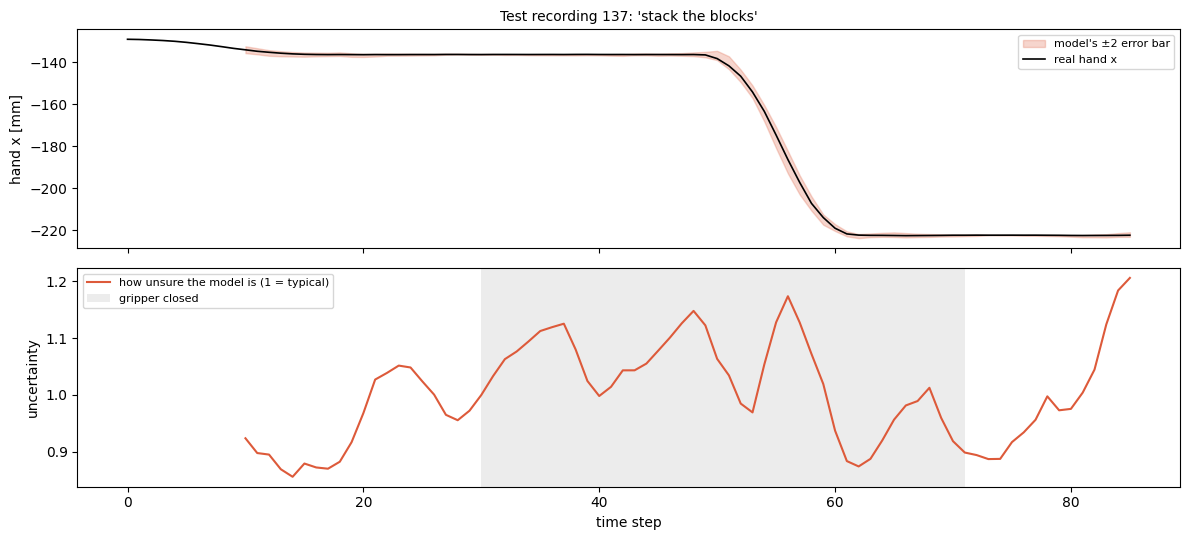

➜ Result: the model is up to 1.2x less sure at its hardest moment than at a typical moment


In [2]:
t0 = time.time()
exp0 = oc.Experiment(rec, seed=SEEDS[0])
res0 = exp0.run()
print(f"(seed {SEEDS[0]} trained and tested in {time.time() - t0:.0f}s)")

i = exp0.TEST[0]
z = exp0.Z[i]
K = exp0.K
W = np.lib.stride_tricks.sliding_window_view(z, K, axis=0).transpose(0, 2, 1)[:len(z) - K]
P, S = exp0.predict("Uncertainty-aware GRU", np.ascontiguousarray(W))
x = exp0.XYZ[0]
to_mm = lambda v: (v * exp0.SD[x] + exp0.MU[x]) * 1000
t = np.arange(K, len(z))
mean_next = to_mm(z[K - 1:len(z) - 1, x] + P[:, 0, x])
band = 2 * S[:, 0, x] * exp0.SD[x] * 1000

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].fill_between(t, mean_next - band, mean_next + band, color="#dd5a3a", alpha=0.25, label="model's ±2 error bar")
axes[0].plot(np.arange(len(z)), to_mm(z[:, x]), color="k", lw=1.2, label="real hand x")
axes[0].set_ylabel("hand x [mm]"); axes[0].legend(fontsize=8)
axes[0].set_title(f"Test recording {i}: '{rec['instructions'][i]}'", fontsize=10)
sure = S[:, 0, exp0.CONT].mean(1)
axes[1].plot(t, sure / np.median(sure), color="#dd5a3a", label="how unsure the model is (1 = typical)")
g = rec["states"][i][:, exp0.GRIPPER]
axes[1].fill_between(np.arange(len(g)), 0, 1, where=g > 0.5, transform=axes[1].get_xaxis_transform(),
                     color="grey", alpha=0.15, lw=0, label="gripper closed")
axes[1].set_ylabel("uncertainty"); axes[1].set_xlabel("time step"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"➜ Result: the model is up to {sure.max() / np.median(sure):.1f}x less sure at its hardest moment than at a typical moment")

## Step 3 — Repeat everything 5 times

**What we do:** for each of 5 random seeds, the recordings are split differently into train / validation / test (70 / 15 / 15 %), all seven methods are trained again, and all failure tests are run again. Seed 0 was already done in Step 2.

**What we get:** 5 results for every number, so we can report **average ± spread** and see whether differences between methods are real or just luck.

In [3]:
results, experiments = [res0], [exp0]
t_all = time.time()
for seed in SEEDS[1:]:
    print(f"seed {seed}:")
    e = oc.Experiment(rec, seed=seed)
    results.append(e.run())
    experiments.append(e)
print(f"➜ Result: {len(SEEDS)} complete runs in {(time.time() - t_all) / 60:.1f} min (plus seed 0)")

forecast = pd.concat([r["forecast"] for r in results], ignore_index=True)
detection = pd.concat([r["detection"] for r in results], ignore_index=True)
small = pd.concat([r["small"] for r in results], ignore_index=True)
forecast.to_csv(os.path.join(RESULTS_DIR, "final_forecasting_all_seeds.csv"), index=False)
detection.to_csv(os.path.join(RESULTS_DIR, "final_detection_all_seeds.csv"), index=False)
small.to_csv(os.path.join(RESULTS_DIR, "final_small_failures_all_seeds.csv"), index=False)

def mean_pm_std(series_by_seed):
    """'0.812 ± 0.013' from a Series indexed by (method, seed)."""
    g = series_by_seed.groupby(level=0)
    return g.mean(), g.std()

def show(mean, std, digits=3):
    return mean.round(digits).astype(str) + " ± " + std.round(digits).astype(str)

seed 1:


  trained: GRU forecaster 7s, Uncertainty-aware GRU 6s, Transformer forecaster 18s, LSTM autoencoder 11s, Isolation Forest 0s


  seed 1 done in 46s
seed 2:


  trained: GRU forecaster 10s, Uncertainty-aware GRU 5s, Transformer forecaster 17s, LSTM autoencoder 10s, Isolation Forest 0s


  seed 2 done in 47s
seed 3:


  trained: GRU forecaster 5s, Uncertainty-aware GRU 5s, Transformer forecaster 10s, LSTM autoencoder 10s, Isolation Forest 0s


  seed 3 done in 35s
seed 4:


  trained: GRU forecaster 10s, Uncertainty-aware GRU 5s, Transformer forecaster 18s, LSTM autoencoder 10s, Isolation Forest 0s


  seed 4 done in 49s
➜ Result: 5 complete runs in 3.0 min (plus seed 0)


## Step 4 — RQ1: How well can the motion be predicted?

**What we get:** the error of the predicted hand position, averaged over the 5 runs (± = spread between runs).

In [4]:
col = "hand error 10 steps [mm]"
m1, s1 = mean_pm_std(forecast.set_index(["method", "seed"])["hand error 1 step [mm]"])
m10, s10 = mean_pm_std(forecast.set_index(["method", "seed"])[col])
rq1 = pd.DataFrame({"1 step ahead [mm]": show(m1, s1, 1), "10 steps ahead [mm]": show(m10, s10, 1)}).loc[m10.sort_values().index]
rq1.to_csv(os.path.join(RESULTS_DIR, "final_rq1.csv"))
display(rq1)
best = m10.idxmin()
print(f"➜ Result (RQ1): learned models predict the hand {m10[best]:.0f}–{m10.drop(['Rule: stays still', 'Rule: keeps its speed']).max():.0f} mm "
      f"accurately 10 steps ahead, vs {m10['Rule: keeps its speed']:.0f} mm and {m10['Rule: stays still']:.0f} mm for the rules.")

,1 step ahead [mm],10 steps ahead [mm]
method,,
GRU forecaster,1.0 ± 0.1,15.6 ± 1.3
Transformer forecaster,0.9 ± 0.0,16.7 ± 0.7
Uncertainty-aware GRU,1.1 ± 0.1,17.6 ± 0.8
Rule: keeps its speed,1.6 ± 0.1,59.2 ± 1.7
Rule: stays still,6.8 ± 0.2,66.0 ± 1.5


➜ Result (RQ1): learned models predict the hand 16–18 mm accurately 10 steps ahead, vs 59 mm and 66 mm for the rules.


## Step 5 — RQ2: Which method detects failures best?

Detection score (ROC-AUC): **1.0 = perfect, 0.5 = guessing**, averaged over 5 runs.

,average,jerk,freeze,drift,noise
method,,,,,
Uncertainty-aware GRU,0.91 ± 0.007,0.981 ± 0.003,0.778 ± 0.023,0.888 ± 0.012,0.99 ± 0.002
GRU forecaster,0.896 ± 0.008,0.973 ± 0.004,0.807 ± 0.026,0.813 ± 0.005,0.989 ± 0.002
Transformer forecaster,0.886 ± 0.007,0.977 ± 0.003,0.765 ± 0.024,0.813 ± 0.007,0.988 ± 0.001
LSTM autoencoder,0.769 ± 0.014,0.94 ± 0.007,0.354 ± 0.044,0.815 ± 0.006,0.965 ± 0.003
Rule: keeps its speed,0.682 ± 0.009,0.983 ± 0.002,0.283 ± 0.02,0.474 ± 0.029,0.988 ± 0.001
Rule: stays still,0.563 ± 0.008,0.693 ± 0.027,0.106 ± 0.007,0.535 ± 0.012,0.917 ± 0.005
Isolation Forest,0.526 ± 0.01,0.601 ± 0.028,0.156 ± 0.011,0.516 ± 0.015,0.831 ± 0.009


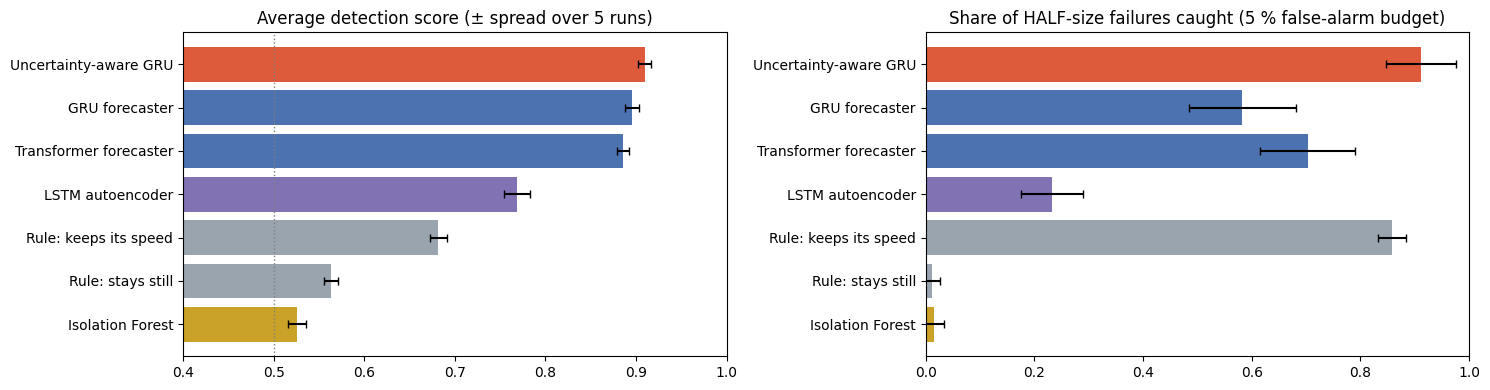

➜ Result (RQ2): best method = Uncertainty-aware GRU (0.910 ± 0.007)
   fast failures: best rule 0.986 vs best method 0.986 (Uncertainty-aware GRU)
   slow failures: best rule 0.378 vs best method 0.833 (Uncertainty-aware GRU)
   half-size failures caught: Uncertainty-aware GRU 91%, Rule: keeps its speed 86%, Transformer forecaster 70%


In [5]:
auc = detection.groupby(["method", "failure"])["ROC-AUC"].agg(["mean", "std"])
avg_by_seed = detection.groupby(["method", "seed"])["ROC-AUC"].mean()
am, asd = mean_pm_std(avg_by_seed)
order = am.sort_values(ascending=False).index

table = pd.DataFrame({f: show(auc["mean"].xs(f, level="failure"), auc["std"].xs(f, level="failure"))
                      for f in oc.FAILURES})
table.insert(0, "average", show(am, asd))
table = table.loc[order]
table.to_csv(os.path.join(RESULTS_DIR, "final_rq2_auc.csv"))
display(table)

colors = {"rule": "#9aa4ae", "classic": "#c9a227", "rebuild": "#8172b3", "predict": "#4c72b0", "new idea": "#dd5a3a"}
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
o = am.sort_values()
axes[0].barh(o.index, o.values, xerr=asd[o.index], color=[colors[oc.FAMILY[n]] for n in o.index], capsize=3)
axes[0].axvline(0.5, color="grey", ls=":", lw=1); axes[0].set_xlim(0.4, 1.0)
axes[0].set_title("Average detection score (± spread over 5 runs)")
sm = small.groupby(["method", "seed"])["detection rate"].mean()
sm_m, sm_s = mean_pm_std(sm)
o2 = sm_m.loc[o.index]
axes[1].barh(o2.index, o2.values, xerr=sm_s[o2.index], color=[colors[oc.FAMILY[n]] for n in o2.index], capsize=3)
axes[1].set_xlim(0, 1.0); axes[1].set_title("Share of HALF-size failures caught (5 % false-alarm budget)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "final_method_comparison.png"), dpi=150); plt.show()

slow = detection[detection.failure.isin(["freeze", "drift"])].groupby("method")["ROC-AUC"].mean()
fast = detection[detection.failure.isin(["jerk", "noise"])].groupby("method")["ROC-AUC"].mean()
rules = ["Rule: stays still", "Rule: keeps its speed"]
print(f"➜ Result (RQ2): best method = {order[0]} ({am[order[0]]:.3f} ± {asd[order[0]]:.3f})")
print(f"   fast failures: best rule {fast[rules].max():.3f} vs best method {fast.max():.3f} ({fast.idxmax()})")
print(f"   slow failures: best rule {slow[rules].max():.3f} vs best method {slow.max():.3f} ({slow.idxmax()})")
print(f"   half-size failures caught: " + ", ".join(f"{n} {sm_m[n]:.0%}" for n in sm_m.sort_values(ascending=False).index[:3]))

## Step 6 — RQ3: Does knowing "how sure it is" reduce false alarms?

**What we compare:** the normal **GRU forecaster** and the **uncertainty-aware GRU**. They use the same network design; the only difference is that the new one also predicts its own uncertainty and uses it in the alarm score.

**Measures (all averaged over the 4 failure types):**
- **False alarms when 90 % of failure moments are caught** — set the alarm so that it catches 90 % of the failure moments, then count how many *normal* moments also raise an alarm. Lower is better. This is the direct test of *"fewer false alarms without missing more failures"*.
- **Detection score** (ROC-AUC) and **share of half-size failures caught** — to check that it does not miss more failures.
- **Alarm steps per clean recording** — how noisy the alarm is on completely normal recordings (at the 5 % budget).

**What we get:** the result of each run side by side, and how many of the 5 runs the new model wins.

In [6]:
pair = ["GRU forecaster", "Uncertainty-aware GRU"]
per_seed = detection[detection.method.isin(pair)].groupby(["seed", "method"]).agg(
    fa90=("false alarms @90% caught", "mean"), auc=("ROC-AUC", "mean"),
    alarm_steps=("alarm steps per clean recording", "first"))
per_seed["small caught"] = small[small.method.isin(pair)].groupby(["seed", "method"])["detection rate"].mean()
wide = per_seed.unstack("method")
wide.columns = [f"{m} | {c}" for c, m in wide.columns]
display(per_seed.unstack("method").round(3))

g, u = per_seed.xs(pair[0], level="method"), per_seed.xs(pair[1], level="method")
wins = {"fewer false alarms @90% caught": int((u.fa90 < g.fa90).sum()),
        "higher detection score": int((u.auc > g.auc).sum()),
        "more half-size failures caught": int((u["small caught"] > g["small caught"]).sum()),
        "fewer alarm steps on clean recordings": int((u.alarm_steps < g.alarm_steps).sum())}
summary3 = pd.DataFrame({
    "GRU forecaster": [f"{g.fa90.mean():.3f} ± {g.fa90.std():.3f}", f"{g.auc.mean():.3f} ± {g.auc.std():.3f}",
                       f"{g['small caught'].mean():.2f} ± {g['small caught'].std():.2f}", f"{g.alarm_steps.mean():.2f} ± {g.alarm_steps.std():.2f}"],
    "Uncertainty-aware GRU": [f"{u.fa90.mean():.3f} ± {u.fa90.std():.3f}", f"{u.auc.mean():.3f} ± {u.auc.std():.3f}",
                              f"{u['small caught'].mean():.2f} ± {u['small caught'].std():.2f}", f"{u.alarm_steps.mean():.2f} ± {u.alarm_steps.std():.2f}"],
    f"runs won by new model (of {len(SEEDS)})": list(wins.values()),
}, index=["false alarms @90% caught (lower = better)", "detection score (higher = better)",
          "half-size failures caught (higher = better)", "alarm steps per clean recording (lower = better)"])
summary3.to_csv(os.path.join(RESULTS_DIR, "final_rq3.csv"))
display(summary3)

n = len(SEEDS)
fewer_fa = wins["fewer false alarms @90% caught"] >= n - 1
no_worse = (u.auc.mean() >= g.auc.mean() - 0.005) and (u["small caught"].mean() >= g["small caught"].mean() - 0.02)
if fewer_fa and no_worse:
    RQ3_VERDICT = "YES: fewer false alarms in almost every run, without missing more failures."
elif fewer_fa:
    RQ3_VERDICT = "PARTLY: fewer false alarms, but it misses more failures."
elif no_worse and (u.auc.mean() > g.auc.mean() + 0.005 or u["small caught"].mean() > g["small caught"].mean() + 0.05):
    RQ3_VERDICT = ("NOT FOR FALSE ALARMS, BUT IT DETECTS BETTER: false alarms are about the same, "
                   "while it catches more failures.")
else:
    RQ3_VERDICT = "NO: no clear improvement over the normal GRU."
print("➜ Result (RQ3):", RQ3_VERDICT)

fa90                                  auc                          alarm_steps                         small caught                      
method GRU forecaster Uncertainty-aware GRU GRU forecaster Uncertainty-aware GRU GRU forecaster Uncertainty-aware GRU GRU forecaster Uncertainty-aware GRU
seed                                                                                                                                                      
0               0.248                 0.248          0.882                 0.898          1.045                 1.197          0.424                 0.884
1               0.198                 0.206          0.900                 0.911          0.848                 2.379          0.576                 0.970
2               0.180                 0.181          0.902                 0.918          1.333                 1.394          0.636                 0.939
3               0.221                 0.228          0.900                 0.910          0.242                 0.000          0.591                 0.813
4               0.212                 0.212          0.895                 0.910          1.106                 0.348          0.687                 0.955

,GRU forecaster,Uncertainty-aware GRU,runs won by new model (of 5)
false alarms @90% caught (lower = better),0.212 ± 0.026,0.215 ± 0.025,1
detection score (higher = better),0.896 ± 0.008,0.910 ± 0.007,5
half-size failures caught (higher = better),0.58 ± 0.10,0.91 ± 0.06,5
alarm steps per clean recording (lower = better),0.92 ± 0.41,1.06 ± 0.94,2


➜ Result (RQ3): NOT FOR FALSE ALARMS, BUT IT DETECTS BETTER: false alarms are about the same, while it catches more failures.


## Step 7 — Real unusual recordings: what actually happened?

**What we do:** use the best learned method from seed 0 on **all 443 recordings**, without adding any failure, and rank them by their highest score. For the top 3, show the **camera frames around the most unusual moment**, the hand position and the score.

**What we get:** real examples to discuss in the thesis. If they show real problems (a hesitation, a slip, a glitch), the method finds things that matter.

In [7]:
learned = [m for m in am.index if oc.FAMILY[m] in ("predict", "new idea")]
DET = am[learned].idxmax()
real = []
for i in range(len(rec["states"])):
    s = exp0.score(DET, exp0.Z[i])
    real.append({"recording": i, "task": rec["instructions"][i], "peak / threshold": float(np.nanmax(s) / exp0.THRESH[DET]),
                 "peak at step": int(np.nanargmax(s)), "length": len(s),
                 "split (seed 0)": "train" if i in exp0.TRAIN else ("val" if i in exp0.VAL else "test")})
real = pd.DataFrame(real).sort_values("peak / threshold", ascending=False).reset_index(drop=True)
real.to_csv(os.path.join(RESULTS_DIR, "final_real_recording_ranking.csv"), index=False)
print(f"Method used: {DET}")
display(real.head(8).round(2))
print(f"➜ Result: {(real['peak / threshold'] > 1).sum()} of {len(real)} recordings cross the alarm threshold")

Method used: Uncertainty-aware GRU


,recording,task,peak / threshold,peak at step,length,split (seed 0)
0,293,stack red and yellow blocks,86.59,74,129,test
1,436,stack the cups,2.97,11,152,test
2,416,stack the cups,2.78,13,121,test
3,154,place the yellow block on the blue block,2.33,26,115,train
4,204,stack the cups,1.90,72,141,val
5,353,stack white cylinder on blue cylinder,1.69,79,96,val
6,31,stack the blocks,1.09,18,130,test
7,124,stack the cups,1.09,91,104,test


➜ Result: 10 of 443 recordings cross the alarm threshold


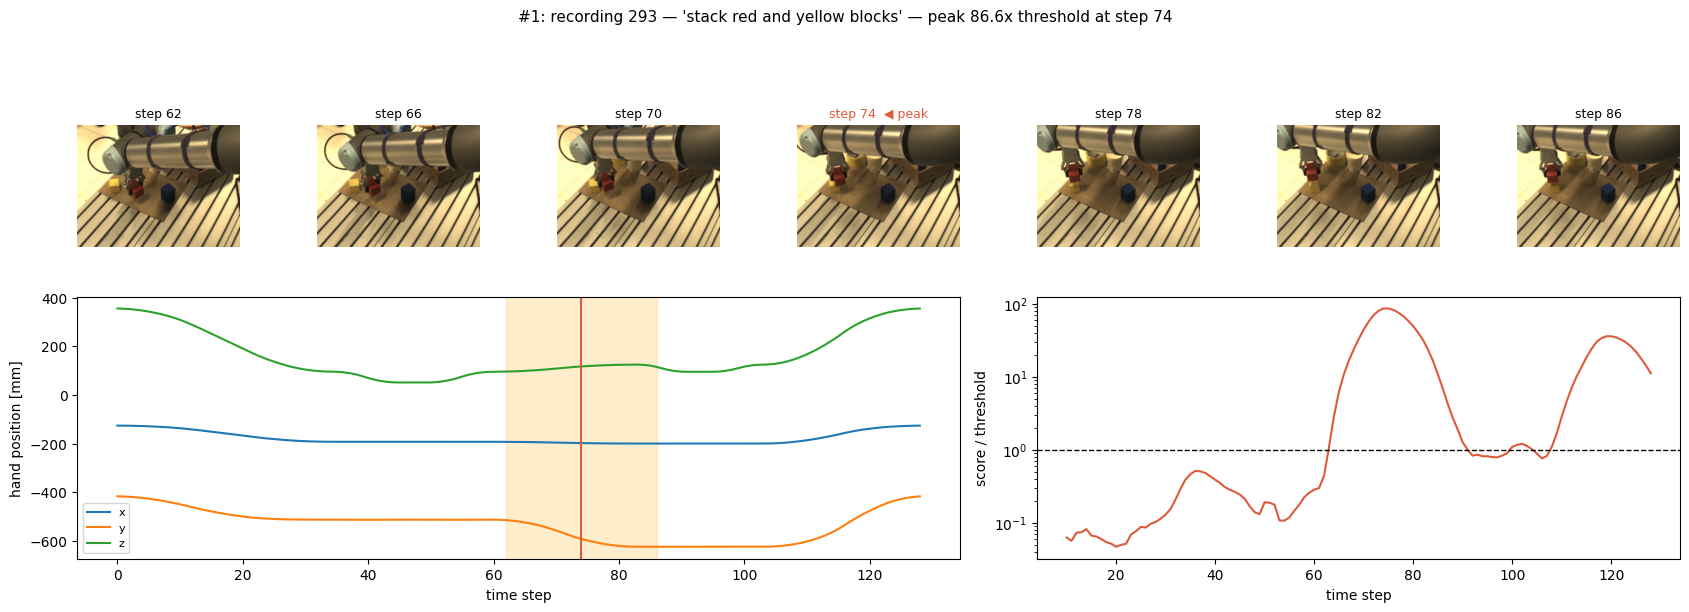

   recording 293: hand moves 10 mm in one step near the peak (typical step: 5.6 mm)


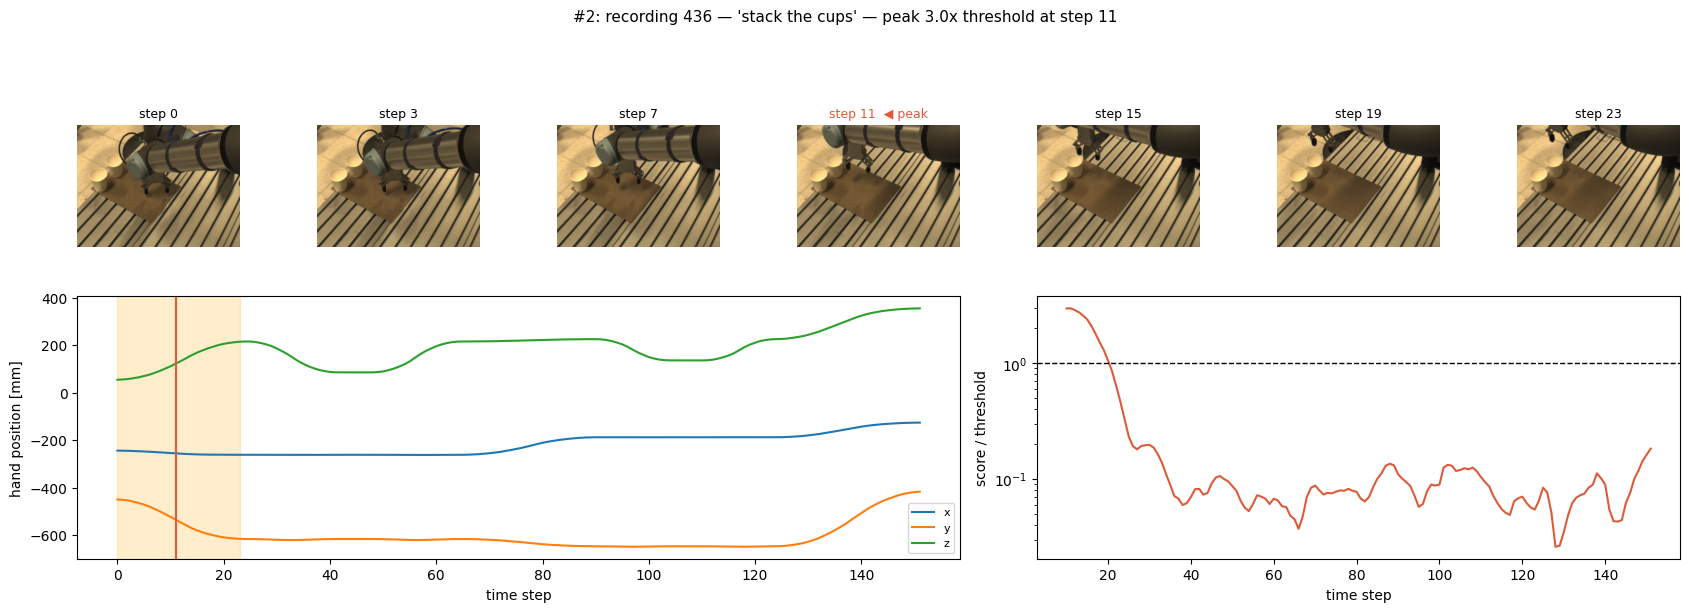

   recording 436: hand moves 17 mm in one step near the peak (typical step: 6.0 mm)


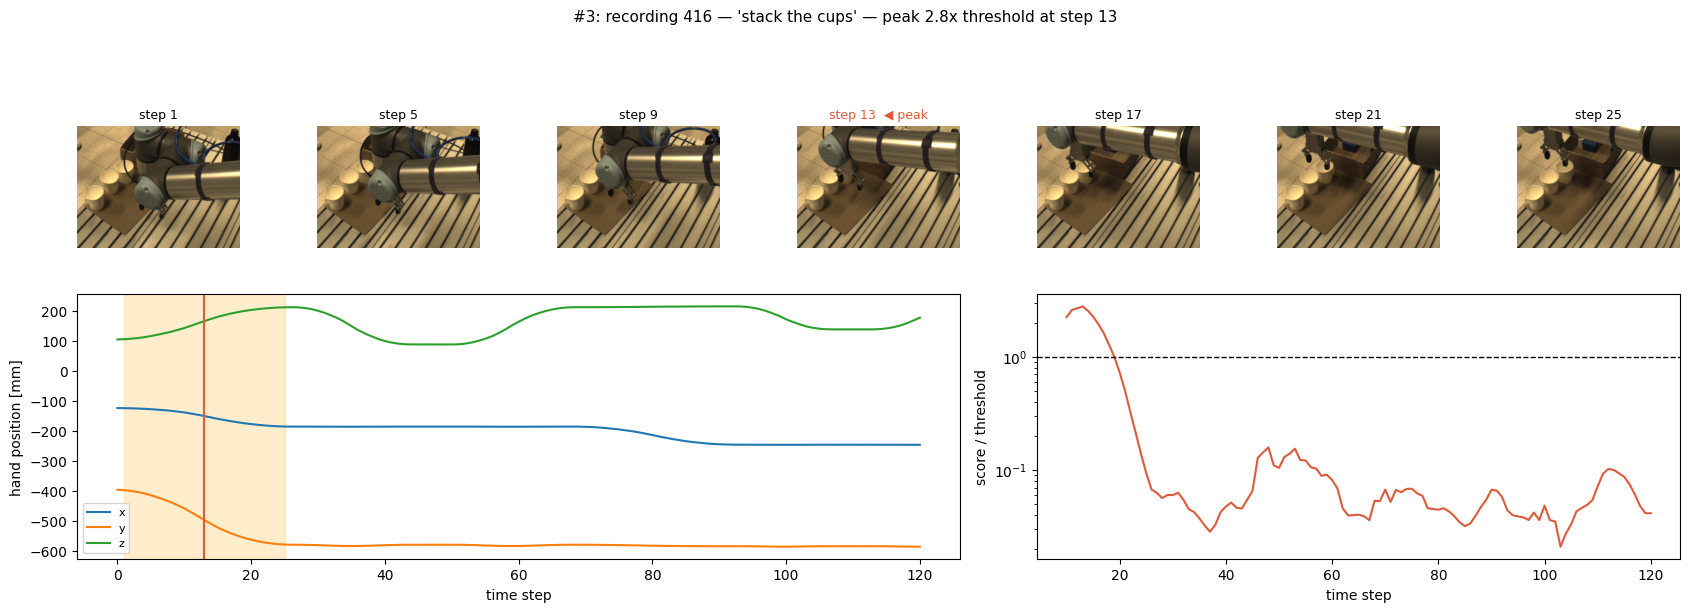

   recording 416: hand moves 16 mm in one step near the peak (typical step: 4.3 mm)


In [8]:
HAVE_IMAGES = os.path.exists(os.path.join(DATASET_PATH, "dataset_info.json"))
if HAVE_IMAGES:
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")
    import tensorflow_datasets as tfds
    builder = tfds.builder_from_directory(DATASET_PATH)

OFFSETS = [-12, -8, -4, 0, 4, 8, 12]
for rank in range(3):
    r = real.iloc[rank]
    i, peak = int(r.recording), int(r["peak at step"])
    st = rec["states"][i]
    s = exp0.score(DET, exp0.Z[i]) / exp0.THRESH[DET]
    steps = [int(np.clip(peak + o, 0, len(st) - 1)) for o in OFFSETS]
    fig = plt.figure(figsize=(17, 6.2))
    gs = fig.add_gridspec(2, len(OFFSETS), height_ratios=[1.1, 1])
    if HAVE_IMAGES:
        ep = next(iter(builder.as_dataset(split=f"train[{i}:{i + 1}]")))
        frames = [f["observation"]["image"] for f in tfds.as_numpy(ep["steps"])]
        for k, t in enumerate(steps):
            ax = fig.add_subplot(gs[0, k]); ax.imshow(frames[t]); ax.axis("off")
            ax.set_title(f"step {t}" + ("  ◀ peak" if t == peak else ""), fontsize=9,
                         color="#dd5a3a" if t == peak else "black")
    ax1 = fig.add_subplot(gs[1, :4])
    for d, name in zip(exp0.XYZ, ["x", "y", "z"]):
        ax1.plot(st[:, d] * 1000, label=name)
    ax1.axvspan(steps[0], steps[-1], color="orange", alpha=0.2); ax1.axvline(peak, color="#dd5a3a", lw=1.5)
    ax1.set_ylabel("hand position [mm]"); ax1.set_xlabel("time step"); ax1.legend(fontsize=8)
    ax2 = fig.add_subplot(gs[1, 4:])
    ax2.plot(s, color="#dd5a3a"); ax2.axhline(1, color="k", ls="--", lw=1)
    ax2.set_yscale("log"); ax2.set_ylabel("score / threshold"); ax2.set_xlabel("time step")
    fig.suptitle(f"#{rank + 1}: recording {i} — '{r.task}' — peak {r['peak / threshold']:.1f}x threshold at step {peak}", fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"real_recording_{i}.png"), dpi=110)
    plt.show()

    move = np.linalg.norm(np.diff(st[:, exp0.XYZ], axis=0), axis=1) * 1000
    lo, hi = max(peak - 3, 0), min(peak + 3, len(move))
    print(f"   recording {i}: hand moves {move[lo:hi].max():.0f} mm in one step near the peak "
          f"(typical step: {np.median(move):.1f} mm)")

### What the camera frames show

*(Written after looking at the three figures above and checking which robot value causes each alarm.)*

**#1 — recording 293, "stack red and yellow blocks" (86× the threshold).** The camera shows a normal moment: the robot carries the red block sideways, and the hand path is smooth. The alarm comes from **joint 4 (a wrist joint)**. In all other recordings this joint almost never moves (99 % of steps change it by less than 0.0001 rad); here it moves up to 0.0007 rad per step, **10× more than anywhere else**, and the hand orientation (`q3`) changes 3.6× more than usual. The movement is real but physically tiny (about 0.04°). Because joint 4 hardly varies in the data, scaling makes this tiny movement look enormous. **Lesson for the thesis:** values that almost never change make detectors over-sensitive; a minimum scale per value (or leaving such values out) should remove this kind of alarm.

**#2 — recording 436 and #3 — recording 416, "stack the cups" (about 3× the threshold).** Both alarms are at the **very start** of the recording (steps 11–13). The frames show a normal reach towards the cups, but the arm starts unusually fast: 16–17 mm per step, while a typical step is 4–6 mm. At the start the model also has the shortest history to predict from. These are **false alarms caused by fast starts**, not failures.

**Conclusion.** None of the top 3 is a real failure, which fits a dataset of successful demonstrations. But every alarm has a clear, explainable cause, and two of them point to concrete improvements: a minimum scale for near-constant values, and extra care at the start of a recording.

## Step 8 — Final answers

In [9]:
print(f"""
RESULTS OVER {len(SEEDS)} RUNS (average ± spread)

RQ1  Prediction: learned models {m10[learned].min():.0f}–{m10[learned].max():.0f} mm error 10 steps ahead,
     vs {m10['Rule: keeps its speed']:.0f} mm ('keeps its speed') and {m10['Rule: stays still']:.0f} mm ('stays still').

RQ2  Detection: best method {order[0]} ({am[order[0]]:.3f} ± {asd[order[0]]:.3f}).
     Fast failures: best rule {fast[rules].max():.2f} ≈ best method {fast.max():.2f}.
     Slow failures: best rule {slow[rules].max():.2f} vs best method {slow.max():.2f}.
     Isolation Forest {am['Isolation Forest']:.2f}, LSTM autoencoder {am['LSTM autoencoder']:.2f}.

RQ3  {RQ3_VERDICT}
     false alarms @90% caught: {g.fa90.mean():.3f} (GRU) vs {u.fa90.mean():.3f} (uncertainty-aware)
     detection score:          {g.auc.mean():.3f} vs {u.auc.mean():.3f}
     half-size failures caught: {g['small caught'].mean():.0%} vs {u['small caught'].mean():.0%}

REAL DATA  {(real['peak / threshold'] > 1).sum()} of {len(real)} recordings cross the alarm threshold;
     the most unusual is recording {real.iloc[0].recording} ('{real.iloc[0].task}').
""")


RESULTS OVER 5 RUNS (average ± spread)

RQ1  Prediction: learned models 16–18 mm error 10 steps ahead,
     vs 59 mm ('keeps its speed') and 66 mm ('stays still').

RQ2  Detection: best method Uncertainty-aware GRU (0.910 ± 0.007).
     Fast failures: best rule 0.99 ≈ best method 0.99.
     Slow failures: best rule 0.38 vs best method 0.83.
     Isolation Forest 0.53, LSTM autoencoder 0.77.

RQ3  NOT FOR FALSE ALARMS, BUT IT DETECTS BETTER: false alarms are about the same, while it catches more failures.
     false alarms @90% caught: 0.212 (GRU) vs 0.215 (uncertainty-aware)
     detection score:          0.896 vs 0.910
     half-size failures caught: 58% vs 91%

REAL DATA  10 of 443 recordings cross the alarm threshold;
     the most unusual is recording 293 ('stack red and yellow blocks').



## Files created

| File | Content |
|---|---|
| `results/final_rq1.csv`, `final_rq2_auc.csv`, `final_rq3.csv` | the three answer tables (average ± spread) |
| `results/final_*_all_seeds.csv` | every number from every run |
| `results/final_real_recording_ranking.csv` | all 443 recordings ranked by how unusual they are |
| `results/figures/*.png` | method comparison and the top real recordings, ready for the thesis |